In [16]:
#Import libraries

import torch
import torch.nn as nn


import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


In [17]:
#Set device

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


Device: cpu


In [18]:
#Load MNIST

transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(
    root="data/raw",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="data/raw",
    train=False,
    download=True,
    transform=transform
)

print("Full training dataset:", len(full_train_dataset))
print("Test dataset:", len(test_dataset))


Full training dataset: 60000
Test dataset: 10000


In [19]:
#Create training and validation datasets
train_size = 50000
val_size = 10000

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))


Training samples: 50000
Validation samples: 10000


In [20]:
#Create DataLoaders

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("DataLoaders created successfully.")


DataLoaders created successfully.


In [21]:
# Define the ANN

class MNIST_ANN_BN_Dropout(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        # Fully connected layer
        self.fc1 = nn.Linear(784, 128)

        # Batch Normalization
        self.bn1 = nn.BatchNorm1d(128)

        # Activation
        self.relu = nn.ReLU()

        # Dropout
        self.dropout = nn.Dropout(0.3)

        # Output layer
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        # 28 x 28 → 784
        x = self.flatten(x)

        # 784 → 128
        x = self.fc1(x)

        # Batch Normalization
        x = self.bn1(x)

        # ReLU
        x = self.relu(x)

        # Dropout
        x = self.dropout(x)

        # 128 → 10
        x = self.fc2(x)

        return x


In [23]:
#Create the model

model = MNIST_ANN_BN_Dropout().to(device)

print(model)


MNIST_ANN_BN_Dropout(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [24]:
#Define loss function

criterion = nn.CrossEntropyLoss()


In [25]:
#Define optimizer

learning_rate = 0.001

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)
plt.show()


In [26]:
#Training function

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Accumulate loss
        total_loss += loss.item()

        # Predictions
        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy


In [27]:
#Validation function
model.eval()


MNIST_ANN_BN_Dropout(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [ ]:
torch.no_grad()


In [ ]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(
                outputs,
                labels
            )

            total_loss += loss.item()

            # Predictions
            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy


In [30]:
#Train the model

epochs = 10

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}


In [31]:
for epoch in range(epochs):

    # Training

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # Validation

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # Save metrics

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    # Print results

    print(
        f"Epoch [{epoch + 1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )


Epoch [1/10] | Train Loss: 0.3547 | Val Loss: 0.1943 | Train Acc: 0.9029 | Val Acc: 0.9426
Epoch [2/10] | Train Loss: 0.2000 | Val Loss: 0.1419 | Train Acc: 0.9421 | Val Acc: 0.9577
Epoch [3/10] | Train Loss: 0.1593 | Val Loss: 0.1196 | Train Acc: 0.9534 | Val Acc: 0.9637
Epoch [4/10] | Train Loss: 0.1392 | Val Loss: 0.1135 | Train Acc: 0.9580 | Val Acc: 0.9678
Epoch [5/10] | Train Loss: 0.1196 | Val Loss: 0.1084 | Train Acc: 0.9632 | Val Acc: 0.9669
Epoch [6/10] | Train Loss: 0.1138 | Val Loss: 0.0993 | Train Acc: 0.9648 | Val Acc: 0.9702
Epoch [7/10] | Train Loss: 0.1037 | Val Loss: 0.0946 | Train Acc: 0.9678 | Val Acc: 0.9713
Epoch [8/10] | Train Loss: 0.0957 | Val Loss: 0.0927 | Train Acc: 0.9701 | Val Acc: 0.9718
Epoch [9/10] | Train Loss: 0.0898 | Val Loss: 0.0907 | Train Acc: 0.9718 | Val Acc: 0.9725
Epoch [10/10] | Train Loss: 0.0817 | Val Loss: 0.0899 | Train Acc: 0.9742 | Val Acc: 0.9726


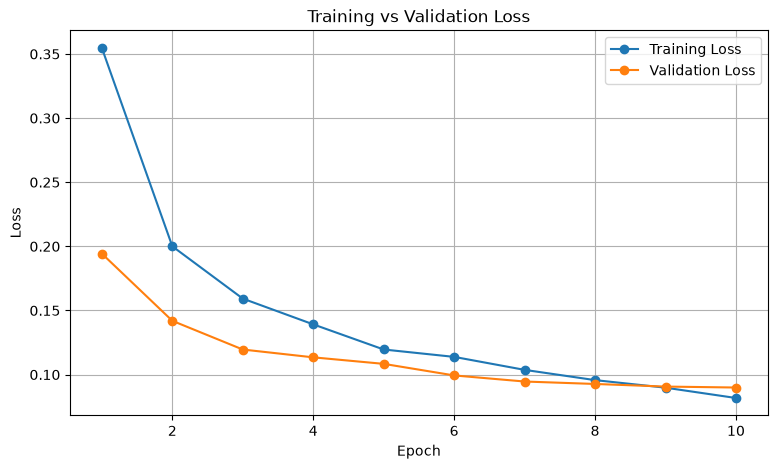

In [32]:
#Plot training vs validation loss

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, epochs + 1),
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, epochs + 1),
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()


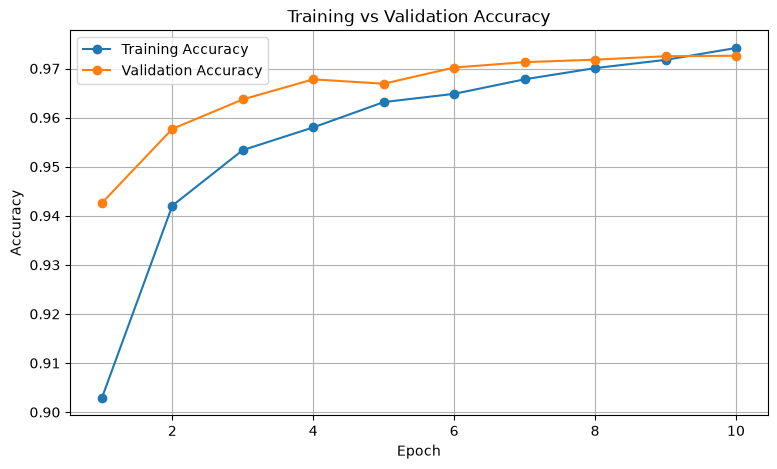

In [33]:
#Plot training vs validation accuracy

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, epochs + 1),
    history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    range(1, epochs + 1),
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()


In [ ]:
#Find best validation accuracy

best_epoch = torch.tensor(
    history["val_accuracy"]
).argmax().item()

best_val_accuracy = history["val_accuracy"][
    best_epoch
]

print(
    "Best Epoch:",
    best_epoch + 1
)

print(
    "Best Validation Accuracy:",
    best_val_accuracy
)


Best Epoch: 10
Best Validation Accuracy: 0.9726


In [ ]:
# Test the final model
test_loss, test_accuracy = validate(
    model,
    test_loader,
    criterion,
    device
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Test Loss: 0.07760362924283495
Test Accuracy: 0.9771


In [39]:
#Save the model

from pathlib import Path
import torch

model_dir = Path("../../models/pytorch")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "mnist_ann_bn_dropout.pth"

torch.save(
    model.state_dict(),
    model_path
)

print("Model saved to:", model_path.resolve())


Model saved to: C:\Users\user\OneDrive\Desktop\Bridgeon\Practical\DeepLearning\DeepLearing-week-1\Project\models\pytorch\mnist_ann_bn_dropout.pth
